In [1]:
import numpy as np
import pandas as pd

from rnd_helper import *
from mot_helper import *

# Notation

$\boldsymbol{w}_i$ and ${r_i}$ are the points and weights for the first density

$\boldsymbol{v}_j$ and ${c_j}$ are the points and weights for the second density

V = $[\boldsymbol{v}_1, ..., \boldsymbol{v}_n]$

W = $[r_1\boldsymbol{w}_1, ..., r_n\boldsymbol{w}_n]$

PV = W

C is Cost Matrix

# Constants

In [24]:
RISK_FREE_RATE: float = 0.05

# Simple Execution

In [25]:
# =======================================
# Data Loading
# =======================================
all_options = pd.read_csv("/Users/nickhofstetter/Documents/ETH/Master/MT/NVDA_historical_data/NVDA_call_prices_210201.csv", index_col=0)
stock = pd.read_csv("/Users/nickhofstetter/Documents/ETH/Master/MT/NVDA_historical_data/NVDA_closing_prices.csv", index_col=0)

S0 = stock.loc['2021-02-01'].values[0]
all_options['spot_price'] = S0
all_options['fetch_date'] = '2021-02-01'
options = all_options[all_options['maturity'] == '19/02/2021']

option_data = all_options
option_data['best_ask'] = option_data['best_ask']/100
option_data['best_bid'] = option_data['best_bid']/100
print(f"Fetched {len(option_data)} option contracts.")
print(f"Spot Price: {option_data['spot_price'].iloc[0]:.2f}")

print("\nCalculating Implied Volatility (this may take a moment)...")
iv_results_df = calculate_iv_for_chain(option_data, r=RISK_FREE_RATE)

maturities = sorted(iv_results_df['time_to_maturity'].unique())

Fetched 594 option contracts.
Spot Price: 13.24

Calculating Implied Volatility (this may take a moment)...


Optimal Transport Plan P shape: (400, 400)
Transport Cost: 0.0011
Max martingale constraint violation |PV - W|: 0.000284
Row marginal violation: 0.000000
Col marginal violation: 0.000000
--- Volatility Metrics ---
Expected Quadratic Variation: 0.001057
Realized Annualized Path Volatility: 23.47%



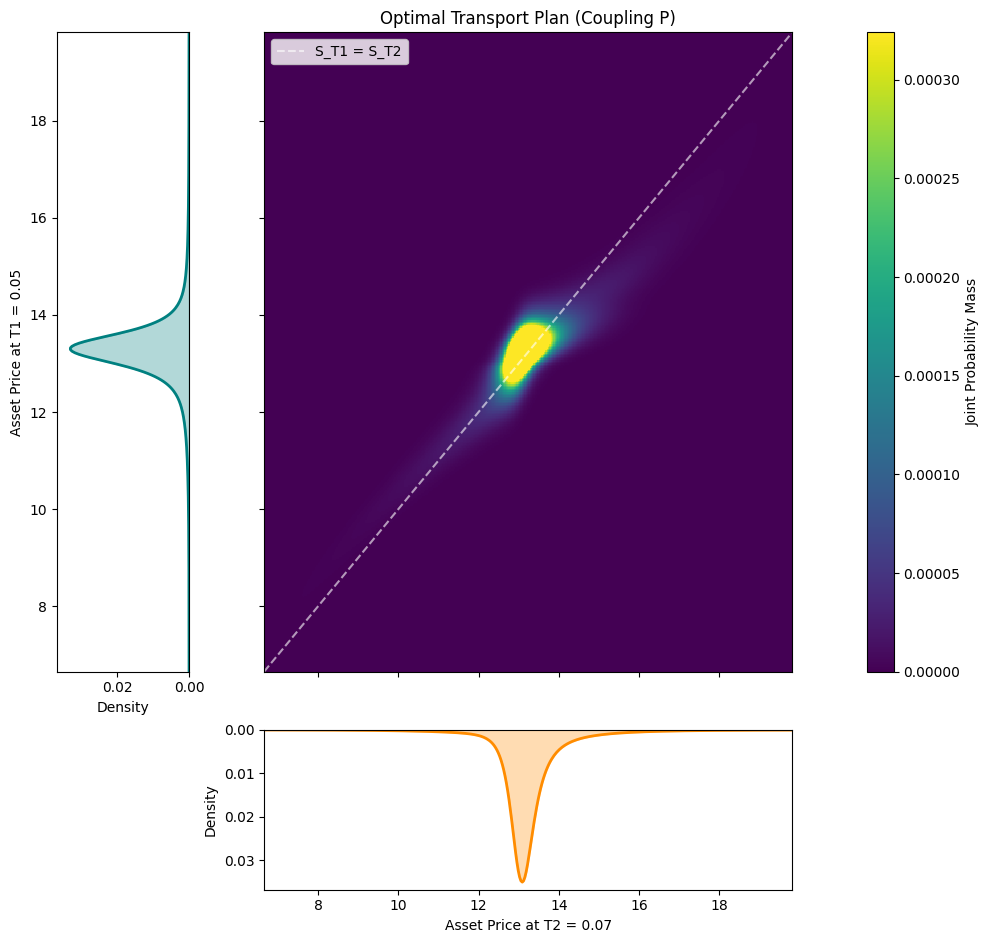

In [23]:
# 1. Fit volatility surface
K_fit_min, K_fit_max = 5, 25
surface_params = fit_surface_svi(iv_results_df, S0, RISK_FREE_RATE, K_fit_min, K_fit_max)

# 2. Select Maturities
maturities = sorted(iv_results_df['time_to_maturity'].unique())
T1 = maturities[2]
T2 = maturities[3]

# 3. Extract RNDs
K1, r_mass = extract_rnd_for_maturity_constrained(surface_params, T1, S0, RISK_FREE_RATE, n_points=402)
K2, c_mass = extract_rnd_for_maturity_constrained(surface_params, T2, S0, RISK_FREE_RATE, n_points=402)

# Convert Prices to Log Returns
X1 = np.log(K1 / S0)
X2 = np.log(K2 / S0)

n = len(K1)
d = 1

# 4. MOT Variables
r = r_mass
c = c_mass

V = np.exp(X2).reshape(n, 1)

expected_expX2_given_X1 = np.exp(X1) * np.exp(RISK_FREE_RATE * (T2 - T1))
W = (r * expected_expX2_given_X1).reshape(n, 1)

# 5. Cost Matrix
base_sq_dist = (X2[None, :] - X1[:, None])**2
C_mot = base_sq_dist

# 6. MOT Algorithm
P_opt, dual_vars, history = sparse_newton_MOT(
    C=C_mot, 
    r=r, 
    c=c, 
    V=V, 
    W=W, 
    N1=5,
    N2=100,
    keep_frac=0.1,
    eps=0.01,
    eta=500.0
)

# 7. Prints
print(f"Optimal Transport Plan P shape: {P_opt.shape}")
print(f"Transport Cost: {np.sum(P_opt * C_mot):.4f}")

PV = P_opt @ V
print(f"Max martingale constraint violation |PV - W|: {np.max(np.abs(PV - W)):.6f}")

print(f"Row marginal violation: {np.max(np.abs(np.sum(P_opt, axis=1) - r.flatten())):.6f}")
print(f"Col marginal violation: {np.max(np.abs(np.sum(P_opt, axis=0) - c.flatten())):.6f}")

expected_quadratic_variation = np.sum(P_opt * base_sq_dist)
dt = T2-T1
realized_path_vol = np.sqrt(expected_quadratic_variation / dt)

print(f"--- Volatility Metrics ---")
print(f"Expected Quadratic Variation: {expected_quadratic_variation:.6f}")
print(f"Realized Annualized Path Volatility: {realized_path_vol:.2%}\n")

plot_mot_coupling(P_opt, K1, K2, r, c, T1, T2)


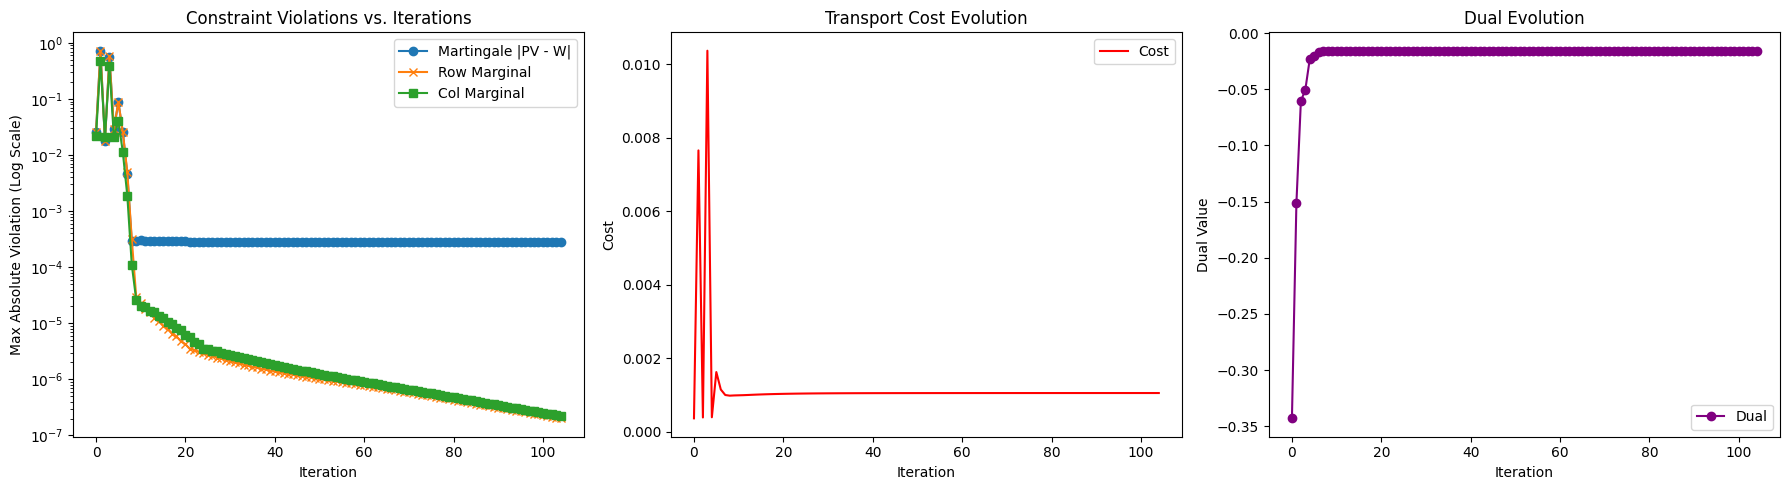

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1. Constraint Violations over Iterations (Log Scale)
axs[0].plot(history['iteration'], history['martingale_violation'], label='Martingale |PV - W|', marker='o')
axs[0].plot(history['iteration'], history['row_violation'], label='Row Marginal', marker='x')
axs[0].plot(history['iteration'], history['col_violation'], label='Col Marginal', marker='s')
axs[0].set_yscale('log')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('Max Absolute Violation (Log Scale)')
axs[0].set_title('Constraint Violations vs. Iterations')
axs[0].legend()

# 2. Objective Function (Transport Cost)
axs[1].plot(history['iteration'], history['transport_cost'], label='Cost', color='red')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Cost')
axs[1].set_title('Transport Cost Evolution')
axs[1].legend()

# 3. Dual Evolution
axs[2].plot(history['iteration'], history['dual'], label='Dual', marker='o', color='purple')
axs[2].set_xlabel('Iteration')
axs[2].set_ylabel('Dual Value')
axs[2].set_title('Dual Evolution')
axs[2].legend()

plt.tight_layout()
plt.show()

# Volatility Controlling Analysis

In [16]:
dt = T2 - T1

base_sq_dist = (X2[None, :] - X1[:, None])**2

# --- Matrix 1: Minimize Path Volatility ---
C_min_vol = base_sq_dist

# --- Matrix 2: Maximize Path Volatility ---
C_max_vol = -base_sq_dist

# --- Matrix 3: Target Volatility (Martingale Schrodinger Bridge) ---
target_sigma = 0.25

C_target_vol = base_sq_dist / (2 * (target_sigma**2) * dt)

# Select the desired regime here:
selected_C = C_max_vol 

regime_eta = 1.0 if selected_C is C_target_vol else 500.0

P_opt, dual_vars, history = sparse_newton_MOT(
    C=selected_C, 
    r=r, 
    c=c, 
    V=V, 
    W=W, 
    N1=5,          
    N2=100,         
    keep_frac=0.1,  
    eps=0.01,
    eta=regime_eta
)

print(f"--- Optimization Results ---")
print(f"Algorithm run with eta = {regime_eta}")
print(f"Optimal Transport Plan P shape: {P_opt.shape}\n")

# --- Path Volatility Calculation ---
expected_quadratic_variation = np.sum(P_opt * base_sq_dist)

realized_path_vol = np.sqrt(expected_quadratic_variation / dt)

print(f"--- Volatility Metrics ---")
print(f"Expected Quadratic Variation: {expected_quadratic_variation:.6f}")
print(f"Realized Annualized Path Volatility: {realized_path_vol:.2%}\n")

# --- Constraint Checks ---
print(f"--- Constraint Diagnostics ---")
PV = P_opt @ V
print(f"Max martingale constraint violation |PV - W|: {np.max(np.abs(PV - W)):.6e}")

print(f"Row marginal violation: {np.max(np.abs(np.sum(P_opt, axis=1) - r.flatten())):.6e}")
print(f"Col marginal violation: {np.max(np.abs(np.sum(P_opt, axis=0) - c.flatten())):.6e}")

Line search failed at outer 0, inner 0; stopping.
--- Optimization Results ---
Algorithm run with eta = 500.0
Optimal Transport Plan P shape: (400, 400)

--- Volatility Metrics ---
Expected Quadratic Variation: 0.009438
Realized Annualized Path Volatility: 70.15%

--- Constraint Diagnostics ---
Max martingale constraint violation |PV - W|: 2.893232e-04
Row marginal violation: 2.006489e-04
Col marginal violation: 7.662591e-05


<>:63: SyntaxWarning: invalid escape sequence '\e'
<>:64: SyntaxWarning: invalid escape sequence '\e'
<>:72: SyntaxWarning: invalid escape sequence '\e'
<>:73: SyntaxWarning: invalid escape sequence '\e'
<>:63: SyntaxWarning: invalid escape sequence '\e'
<>:64: SyntaxWarning: invalid escape sequence '\e'
<>:72: SyntaxWarning: invalid escape sequence '\e'
<>:73: SyntaxWarning: invalid escape sequence '\e'
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_13083/2803148364.py:63: SyntaxWarning: invalid escape sequence '\e'
  axes[0].set_title('Realized Path Volatility vs. $\eta$')
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_13083/2803148364.py:64: SyntaxWarning: invalid escape sequence '\e'
  axes[0].set_xlabel('Entropic Regularization ($\eta$)')
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_13083/2803148364.py:72: SyntaxWarning: invalid escape sequence '\e'
  axes[1].set_title('Max Martingale Violation vs. $\eta$')
/var/folders/hv/bm8vcdrx7_dfrqhgzvtd

Starting Eta Sweep Analysis...

--- Processing MIN Volatility Regime ---
Eta:   1.0 | Vol: 52.87% | Martingale Viol: 5.85e-05 | Marg Viol: 5.15e-11
Eta:   5.0 | Vol: 52.41% | Martingale Viol: 5.93e-05 | Marg Viol: 3.66e-11
Line search reached limit at iter 100. Optimal point reached or stuck.
Eta:  10.0 | Vol: 51.65% | Martingale Viol: 6.11e-05 | Marg Viol: 5.10e-11
Line search reached limit at iter 100. Optimal point reached or stuck.
Eta:  25.0 | Vol: 48.40% | Martingale Viol: 7.18e-05 | Marg Viol: 2.89e-11
Line search reached limit at iter 99. Optimal point reached or stuck.
Eta:  50.0 | Vol: 43.76% | Martingale Viol: 1.04e-04 | Marg Viol: 4.83e-12
Line search reached limit at iter 102. Optimal point reached or stuck.
Eta:  75.0 | Vol: 40.25% | Martingale Viol: 1.34e-04 | Marg Viol: 1.83e-11
Eta: 100.0 | Vol: 37.52% | Martingale Viol: 1.58e-04 | Marg Viol: 2.15e-10
Eta: 200.0 | Vol: 30.97% | Martingale Viol: 2.15e-04 | Marg Viol: 1.93e-08
Eta: 500.0 | Vol: 23.47% | Martingale Viol: 

/Users/nickhofstetter/Documents/ETH/Master/MT/code/eff_algo_mot/mot_helper.py:168: MatrixRankWarning: Matrix is exactly singular
  delta = spsolve(H_damped, -grad_vec_g)


Eta:  50.0 | Vol: 55.27% | Martingale Viol: 6.33e-05 | Marg Viol: 1.19e-09
Line search failed at outer 0, inner 0; stopping.
Eta:  75.0 | Vol: 56.63% | Martingale Viol: 6.48e-05 | Marg Viol: 6.66e-09
Line search failed at outer 0, inner 0; stopping.
Eta: 100.0 | Vol: 57.69% | Martingale Viol: 6.59e-05 | Marg Viol: 2.10e-08
Line search failed at outer 0, inner 0; stopping.
Eta: 200.0 | Vol: 59.78% | Martingale Viol: 6.58e-05 | Marg Viol: 1.19e-06
Line search failed at outer 0, inner 0; stopping.
Eta: 500.0 | Vol: 70.15% | Martingale Viol: 2.89e-04 | Marg Viol: 2.01e-04


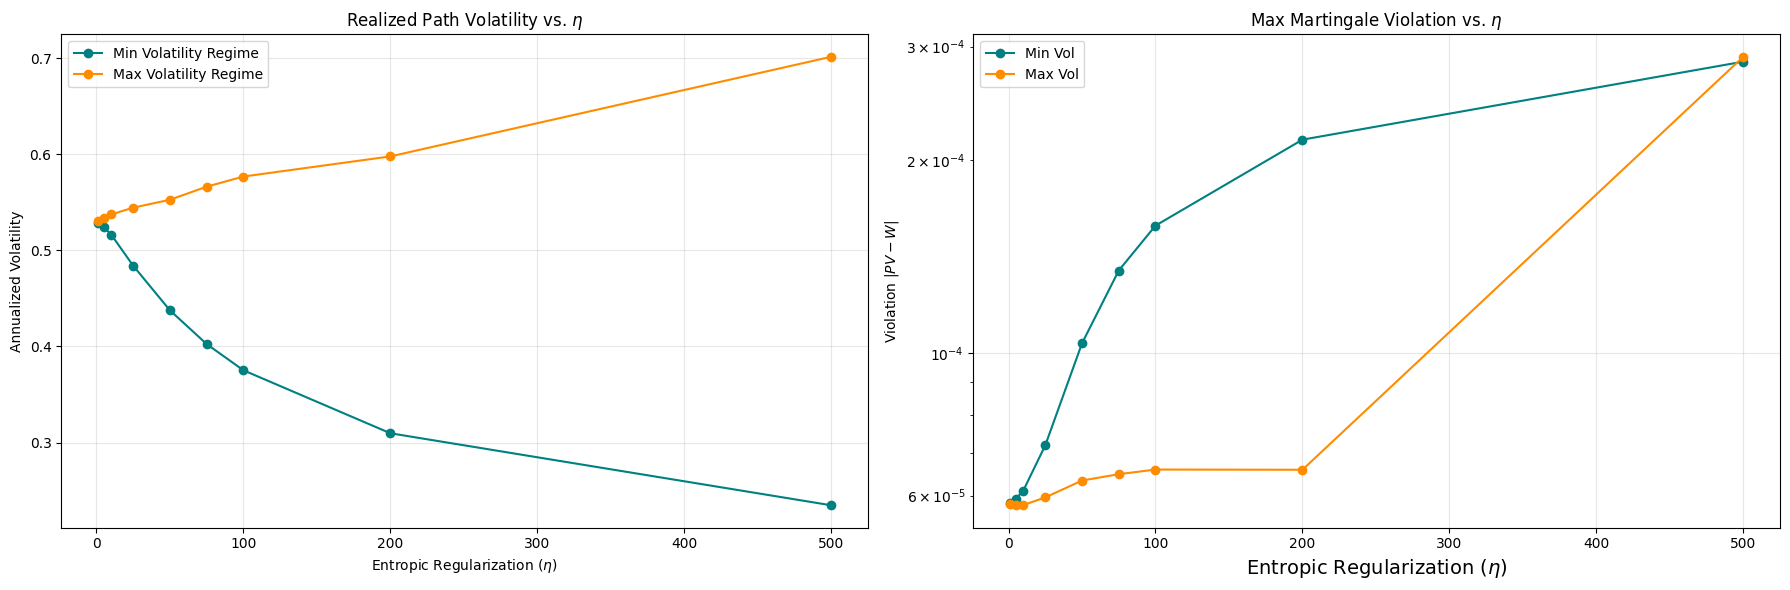

In [18]:
# =====================================================================
# Min / Max Cost Analysis
# ===================================================================== 
eta_values = [1.0, 5.0, 10.0, 25.0, 50.0, 75.0, 100.0, 200.0, 500.0]

metrics = {
    'min': {'vol': [], 'mart_viol': [], 'marg_viol': []},
    'max': {'vol': [], 'mart_viol': [], 'marg_viol': []}
}

regimes = {
    'min': C_min_vol,
    'max': C_max_vol
}

print("Starting Eta Sweep Analysis...")
all_couplings = {'min': [], 'max': []}

for regime_name, C_matrix in regimes.items():
    print(f"\n--- Processing {regime_name.upper()} Volatility Regime ---")
    
    for current_eta in eta_values:        
        P_opt, dual_vars, history = sparse_newton_MOT(
            C=C_matrix, 
            r=r, 
            c=c, 
            V=V, 
            W=W, 
            N1=5,
            N2=100,         
            keep_frac=0.1,  
            eps=0.01,
            eta=current_eta
        )
        
        # 1. Path Volatility Calculation
        expected_quadratic_variation = np.sum(P_opt * base_sq_dist)
        realized_path_vol = np.sqrt(expected_quadratic_variation / dt)
        
        # 2. Constraint Violations
        PV = P_opt @ V
        mart_viol = np.max(np.abs(PV - W))
        
        row_viol = np.max(np.abs(np.sum(P_opt, axis=1) - r.flatten()))
        col_viol = np.max(np.abs(np.sum(P_opt, axis=0) - c.flatten()))
        max_marg_viol = max(row_viol, col_viol)
        
        metrics[regime_name]['vol'].append(realized_path_vol)
        metrics[regime_name]['mart_viol'].append(mart_viol)
        metrics[regime_name]['marg_viol'].append(max_marg_viol)
        
        print(f"Eta: {current_eta:>5.1f} | Vol: {realized_path_vol:>6.2%} | Martingale Viol: {mart_viol:.2e} | Marg Viol: {max_marg_viol:.2e}")
        all_couplings[regime_name].append(P_opt.copy())

# Plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Realized Volatility vs Eta
axes[0].plot(eta_values, metrics['min']['vol'], marker='o', color='teal', label='Min Volatility Regime')
axes[0].plot(eta_values, metrics['max']['vol'], marker='o', color='darkorange', label='Max Volatility Regime')
axes[0].set_title('Realized Path Volatility vs. $\eta$')
axes[0].set_xlabel('Entropic Regularization ($\eta$)')
axes[0].set_ylabel('Annualized Volatility')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Martingale Violation vs Eta
axes[1].plot(eta_values, metrics['min']['mart_viol'], marker='o', color='teal', label='Min Vol')
axes[1].plot(eta_values, metrics['max']['mart_viol'], marker='o', color='darkorange', label='Max Vol')
axes[1].set_title('Max Martingale Violation vs. $\eta$')
axes[1].set_xlabel('Entropic Regularization ($\eta$)', fontsize=14)
axes[1].set_ylabel('Violation $|PV - W|$')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

<>:59: SyntaxWarning: invalid escape sequence '\e'
<>:65: SyntaxWarning: invalid escape sequence '\s'
<>:77: SyntaxWarning: invalid escape sequence '\e'
<>:81: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\e'
<>:65: SyntaxWarning: invalid escape sequence '\s'
<>:77: SyntaxWarning: invalid escape sequence '\e'
<>:81: SyntaxWarning: invalid escape sequence '\s'
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_13083/3644710485.py:59: SyntaxWarning: invalid escape sequence '\e'
  label=f'$\eta$ = {current_eta}'
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_13083/3644710485.py:65: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_xlabel('Target Prior Volatility ($\sigma_0$)')
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_13083/3644710485.py:77: SyntaxWarning: invalid escape sequence '\e'
  label=f'$\eta$ = {current_eta}'
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_13083/3644710485.py:81:

Starting Target Volatility & Eta Sweep...

--- Processing Eta = 1.0 ---
Target Vol:  5.00% | Realized Vol: 12.62% | Violations (Mart/Marg): 3.5e-04 / 6.1e-07
Target Vol:  9.44% | Realized Vol: 14.74% | Violations (Mart/Marg): 3.5e-04 / 2.4e-08
Target Vol: 13.89% | Realized Vol: 17.56% | Violations (Mart/Marg): 3.3e-04 / 1.0e-09
Target Vol: 18.33% | Realized Vol: 20.54% | Violations (Mart/Marg): 3.1e-04 / 4.2e-07
Target Vol: 22.78% | Realized Vol: 23.44% | Violations (Mart/Marg): 2.8e-04 / 1.9e-07
Target Vol: 27.22% | Realized Vol: 26.15% | Violations (Mart/Marg): 2.6e-04 / 8.6e-08
Target Vol: 31.67% | Realized Vol: 28.65% | Violations (Mart/Marg): 2.4e-04 / 2.8e-08
Target Vol: 36.11% | Realized Vol: 30.97% | Violations (Mart/Marg): 2.1e-04 / 1.0e-08
Line search failed at outer 16, inner 0; stopping.
Line search failed at outer 18, inner 0; stopping.
Target Vol: 40.56% | Realized Vol: 33.11% | Violations (Mart/Marg): 2.0e-04 / 2.0e-09
Line search failed at outer 19, inner 0; stopping.
T

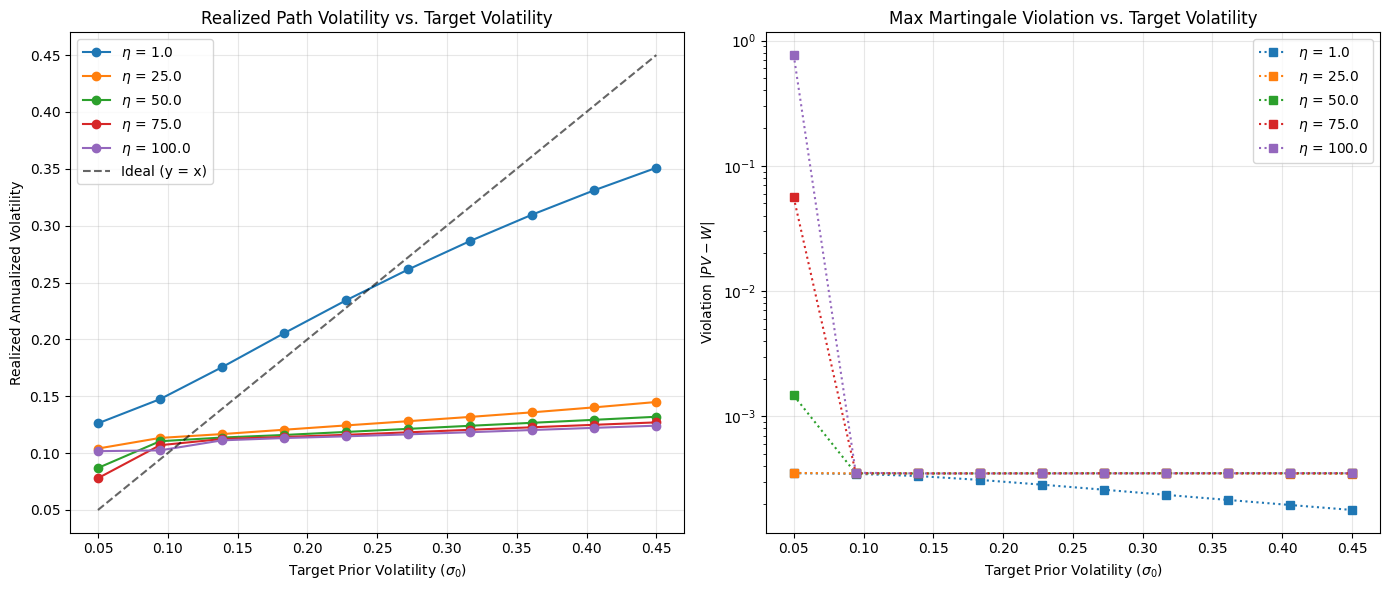

In [20]:
# =====================================================================
# Target Vol Analysis
# =====================================================================
eta_values = [1.0, 25.0, 50.0, 75.0, 100.0]
target_sigmas = np.linspace(0.05, 0.45, 10)

results = {eta: {'realized_vol': [], 'mart_viol': [], 'marg_viol': []} for eta in eta_values}

print("Starting Target Volatility & Eta Sweep...")

for current_eta in eta_values:
    print(f"\n--- Processing Eta = {current_eta} ---")
    
    for target_sigma in target_sigmas:
        C_target_vol = base_sq_dist / (2 * (target_sigma**2) * dt)
        
        P_opt, dual_vars, history = sparse_newton_MOT(
            C=C_target_vol, 
            r=r, 
            c=c, 
            V=V, 
            W=W, 
            N1=20,          
            N2=100,         
            keep_frac=0.1,  
            eps=0.01,
            eta=current_eta
        )
        
        # 1. Path Volatility Calculation
        expected_quadratic_variation = np.sum(P_opt * base_sq_dist)
        realized_path_vol = np.sqrt(expected_quadratic_variation / dt)
        
        # 2. Constraint Violations
        PV = P_opt @ V
        mart_viol = np.max(np.abs(PV - W))
        
        row_viol = np.max(np.abs(np.sum(P_opt, axis=1) - r.flatten()))
        col_viol = np.max(np.abs(np.sum(P_opt, axis=0) - c.flatten()))
        max_marg_viol = max(row_viol, col_viol)
        
        results[current_eta]['realized_vol'].append(realized_path_vol)
        results[current_eta]['mart_viol'].append(mart_viol)
        results[current_eta]['marg_viol'].append(max_marg_viol)
        
        print(f"Target Vol: {target_sigma:>6.2%} | Realized Vol: {realized_path_vol:>6.2%} | Violations (Mart/Marg): {mart_viol:.1e} / {max_marg_viol:.1e}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Target Volatility vs. Realized Volatility for different Etas
for current_eta in eta_values:
    axes[0].plot(
        target_sigmas, 
        results[current_eta]['realized_vol'], 
        marker='o', 
        label=f'$\eta$ = {current_eta}'
    )

axes[0].plot(target_sigmas, target_sigmas, 'k--', alpha=0.6, label='Ideal (y = x)')

axes[0].set_title('Realized Path Volatility vs. Target Volatility')
axes[0].set_xlabel('Target Prior Volatility ($\sigma_0$)')
axes[0].set_ylabel('Realized Annualized Volatility')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Martingale Violations vs. Target Volatility
for current_eta in eta_values:
    axes[1].plot(
        target_sigmas, 
        results[current_eta]['mart_viol'], 
        marker='s', 
        linestyle=':',
        label=f'$\eta$ = {current_eta}'
    )

axes[1].set_title('Max Martingale Violation vs. Target Volatility')
axes[1].set_xlabel('Target Prior Volatility ($\sigma_0$)')
axes[1].set_ylabel('Violation $|PV - W|$')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_13083/65236533.py:34: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"Target $\sigma$: {sigma:.1%}")


Starting Volatility Sweep for fixed Eta = 1.0...
Line search failed at outer 16, inner 0; stopping.
Line search failed at outer 18, inner 0; stopping.
Line search failed at outer 19, inner 0; stopping.


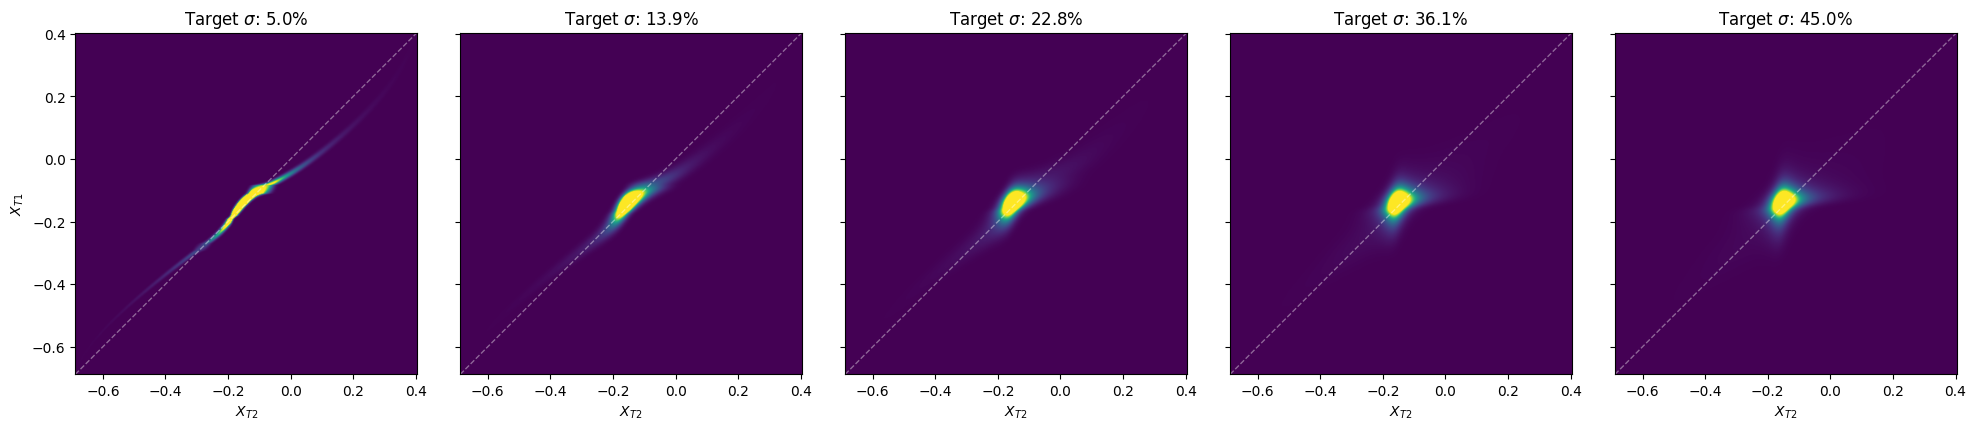

In [21]:
def plot_volatility_evolution(vol_couplings, target_sigmas, K1, K2):
    """
    Plots a row of coupling matrices for increasing target volatilities.
    """
    n_plots = len(vol_couplings)
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), sharey=True)
    
    price_min = min(K1.min(), K2.min())
    price_max = max(K1.max(), K2.max())

    for i, (sigma, P) in enumerate(zip(target_sigmas, vol_couplings)):
        ax = axes[i]
        
        # Use a consistent percentile for the color scale to allow comparison
        vmax = np.percentile(P, 99.7)
        
        # Plot heatmap
        im = ax.imshow(
            P, 
            origin='lower', 
            extent=[K2.min(), K2.max(), K1.min(), K1.max()],
            cmap='viridis', 
            vmax=vmax,
            aspect='equal'
        )
        
        # Reference diagonal
        ax.plot([price_min, price_max], [price_min, price_max], 
                color='white', linestyle='--', alpha=0.4, lw=1)
        
        ax.set_title(f"Target $\sigma$: {sigma:.1%}")
        ax.set_xlabel("$X_{T2}$")
        if i == 0:
            ax.set_ylabel("$X_{T1}$")

    plt.tight_layout()
    plt.show()

# =====================================================================
# Integrated Analysis Loop
# =====================================================================

fixed_eta = 1.0
# We pick a subset of sigmas to plot so the grid isn't too crowded (e.g., every 2nd or 3rd)
plot_indices = [0, 2, 4, 7, 9] 
couplings_to_plot = []
sigmas_to_plot = []

print(f"Starting Volatility Sweep for fixed Eta = {fixed_eta}...")

for i, target_sigma in enumerate(target_sigmas):
    C_target_vol = base_sq_dist / (2 * (target_sigma**2) * dt)
    
    P_opt, _, _ = sparse_newton_MOT(
        C=C_target_vol, 
        r=r, c=c, V=V, W=W, 
        N1=20, N2=100, 
        keep_frac=0.1, eps=0.01,
        eta=fixed_eta
    )
    
    # Only store the ones we want to visualize
    if i in plot_indices:
        couplings_to_plot.append(P_opt.copy())
        sigmas_to_plot.append(target_sigma)
    
    # ... (Keep your metrics storage code here if needed) ...

# Final Plot
plot_volatility_evolution(couplings_to_plot, sigmas_to_plot, X1, X2)